# **🔖 Regression Pipeline 01**

**Dataset:**

- California Housing dataset from sklearn, containing numerical features for regression.

**Pipeline Components:**

- `ColumnTransformer` for preprocessing:

  - `StandardScaler` applied to numerical features.

  - `OneHotEncoder` applied to categorical features

- `Pipeline` from sklearn.pipeline used to chain preprocessing and modeling steps.

**Model:**

- `Ridge` regression (can be swapped easily).

**Hyperparameter Tuning:**

- `GridSearchCV` used for cross-validated hyperparameter optimization (e.g., tuning alpha in Ridge).

**Evaluation Metrics:**

- Comprehensive set including `R², MAE, MSE, RMSE, MAPE, Median AE, Max Error, Explained Variance`.

**Visualization (Optional):**

- Residual plots, predicted vs actual, and error distributions can be added for model diagnostics.

---
# **⬜ Import dependencies**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error, mean_squared_log_error,
    max_error, median_absolute_error, explained_variance_score
)

---
# **⬜ Load from sk-learn**

In [2]:
# Load dataset
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

In [3]:
# Simulate some categorical features
X['Region'] = pd.qcut(X['AveRooms'], q=3, labels=['Low', 'Medium', 'High'])

---
# **🟨 Train-test split**

In [4]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Identify feature types
num_features = X.select_dtypes(include='number').columns.tolist()
cat_features = X.select_dtypes(include='object').columns.tolist()

---
# **🟨 Column Transformer**

In [6]:
# Preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

---
# **🟨 Training Pipeline**

In [7]:
# Define pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

In [8]:
# Grid search for alpha
param_grid = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

In [16]:
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['MedInc',
                                                                          'HouseAge',
                                                                          'AveRooms',
                                                                          'AveBedrms',
                                                                          'Population',
                                                                          'AveOccup',
                                                                          'Latitude',
                                                                          'Longitude']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         [])])),
                                       ('model', Ridge())]),
             param_grid={'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
             scoring='neg_root_mean_squared_error')

In [10]:
# Predictions
y_pred = grid_search.predict(X_test)

---
# **🟩 Model Evaluation**

In [17]:
# Evaluation
print("🔍 Best Params:", grid_search.best_params_)
print("✅ Model Evaluation Metrics:")

metrics = {
    'R2 Score': r2_score(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'MSE': mean_squared_error(y_test, y_pred),
    'RMSE': mean_squared_error(y_test, y_pred),
    'MAPE': mean_absolute_percentage_error(y_test, y_pred),
    'Max Error': max_error(y_test, y_pred),
    'Median AE': median_absolute_error(y_test, y_pred),
    'Explained Variance': explained_variance_score(y_test, y_pred)
}

for k, v in metrics.items():
    print(f"{k:20s}: {v:.4f}")

🔍 Best Params: {'model__alpha': 0.01}
✅ Model Evaluation Metrics:
R2 Score            : 0.5758
MAE                 : 0.5332
MSE                 : 0.5559
RMSE                : 0.5559
MAPE                : 0.3195
Max Error           : 9.8753
Median AE           : 0.4102
Explained Variance  : 0.5758


| Metric             | Description                                     | When to Use                                      |
|----------------------|----------------------------------------------------|----------------------------------------------------|
| `R² Score`           | % of target variance explained by model (0 to 1)  | Default metric to assess overall model fit         |
| `MAE`                | Average of absolute errors                        | Easy to interpret, less sensitive to outliers      |
| `MSE`                | Average of squared errors                         | Penalizes larger errors more heavily               |
| `RMSE`               | Square root of MSE (same units as target)         | Good for interpreting in original units            |
| `MAPE`               | Mean % error relative to actual values            | When percentage error matters (e.g., sales)        |
| `MSLE`               | Like MSE, but on log-transformed values           | For targets that grow exponentially, > 0 only      |
| `Max Error`          | Largest single prediction error                   | For worst-case performance analysis                |
| `Median AE`          | Median of absolute errors                         | Robust to outliers, better than MAE in skewed data |
| `Explained Variance` | Similar to R² but not penalized by bias           | Check model's ability to capture variation         |


---
---
# **🟩 Model Visualization**

---
## **🟩 Actual vs Predicted**

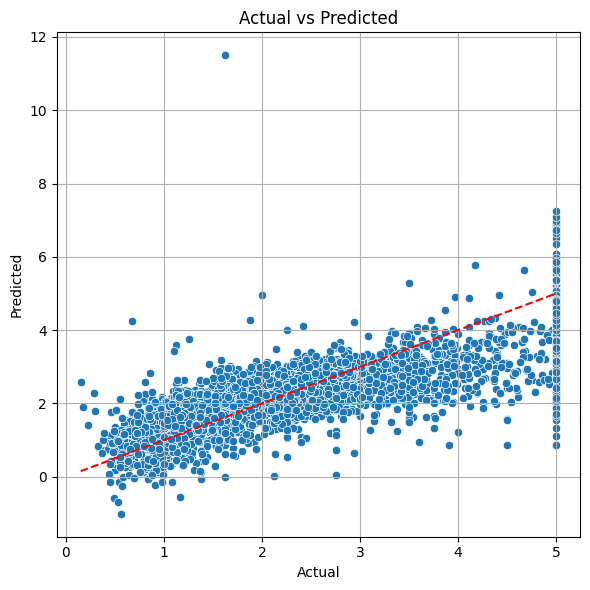

In [18]:
# 1. Actual vs Predicted
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

| Aspect                | Explanation                                                                          |
| --------------------- | ------------------------------------------------------------------------------------ |
| **Purpose**           | Visualize how well the model’s predictions match actual values                       |
| **X-axis**            | Actual target values                                                                 |
| **Y-axis**            | Predicted values by the model                                                        |
| **Ideal Pattern**     | Points lie close to the diagonal line (y = x) indicating perfect predictions         |
| **Deviation Meaning** | Distance from diagonal shows prediction errors; larger distance = larger error       |
| **Usefulness**        | Quick visual check for model accuracy and bias; detects under/over-prediction trends |
| **Limitations**       | Doesn’t quantify error; just visual; complements metrics like RMSE, MAE              |


---
## **🟩 Residual Plot**

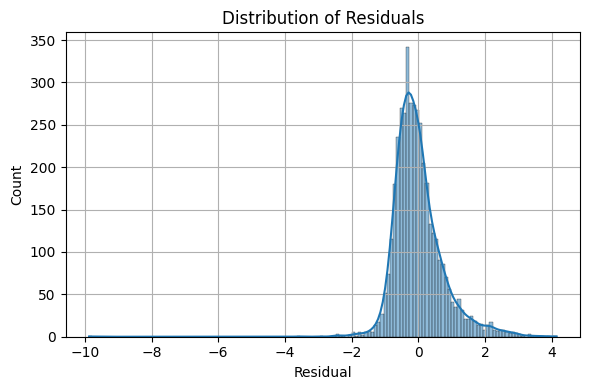

In [19]:
# 2. Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

| Aspect                | Explanation                                                                                                 |
| --------------------- | ----------------------------------------------------------------------------------------------------------- |
| **Purpose**           | Show the distribution of residuals (errors)                                                                 |
| **X-axis**            | Residual values (Actual − Predicted)                                                                        |
| **Y-axis**            | Frequency or density of residual values                                                                     |
| **Ideal Pattern**     | Residuals roughly follow a normal distribution centered around zero                                         |
| **Deviation Meaning** | Skewed or multi-modal distribution suggests model bias or non-normal errors                                 |
| **Usefulness**        | Check if residuals are symmetrically distributed and centered around zero, which supports model assumptions |
| **Limitations**       | Does not show relationship with predicted values or heteroscedasticity                                      |


---
## **🟩 Residuals vs Predicted**

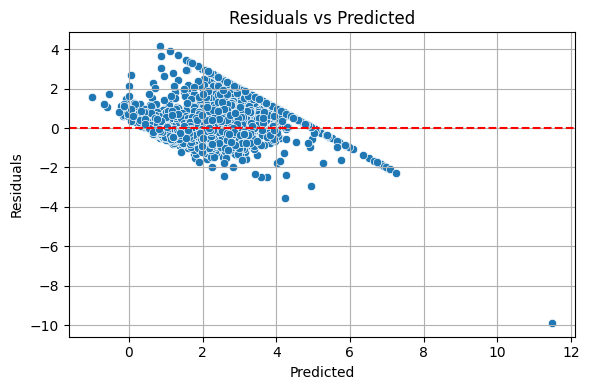

In [20]:
# 3. Residuals vs Predicted
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

| Aspect                | Explanation                                                                     |
| --------------------- | ------------------------------------------------------------------------------- |
| **Plot Type**         | Scatter plot of residuals against predicted values                              |
| **Purpose**           | Check for patterns or bias in residuals relative to predictions                 |
| **X-axis**            | Predicted values                                                                |
| **Y-axis**            | Residuals (Actual − Predicted)                                                  |
| **Ideal Pattern**     | Residuals scattered randomly around zero without clear pattern                  |
| **Deviation Meaning** | Patterns or funnel shapes indicate heteroscedasticity or model misspecification |
| **Usefulness**        | Detects non-constant error variance and systematic prediction errors            |
| **Reference Line**    | Horizontal line at zero residuals for visual baseline                           |


---
---
---